# Exercise 1 

##### Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

##### Linear Congruential Generator

In [3]:
def lcg(n, x0, a, c, m):
    numbers = []
    x = x0
    for _ in range(n):
        x = (a * x + c) % m  
        numbers.append(x / m) 
    return numbers

##### Statistical Tests

In [4]:
def chi_square_test(data, bins=10):
    observed, _ = np.histogram(data, bins=bins)

    expected = len(data) / bins
    return np.sum((observed - expected)**2 / expected)

def kolmogorov_smirnov_test(data):
    data_sorted = np.sort(data)
    n = len(data)
    d_plus = np.max(np.arange(1, n + 1) / n - data_sorted)
    d_minus = np.max(data_sorted - np.arange(0, n) / n)
    return max(d_plus, d_minus)

def correlation_test(data, h=1):
    data = np.array(data) 
    n = len(data)
    c_h = np.mean(data[:-h] * data[h:])
    mu = 1/4
    sigma = np.sqrt(7 / (144 * n))
    z = (c_h - mu) / sigma
    return z

def wald_wolfowitz_test(data):
    n = len(data)
    median = 0.5
    runs = [1 if x > median else -1 for x in data]
    
    r = 1
    for i in range(1, n):
        if runs[i] != runs[i-1]:
            r += 1
            
    n1 = runs.count(1)
    n2 = runs.count(-1)
    
    expected_r = (2 * n1 * n2) / (n1 + n2) + 1
    variance_r = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / ((n1 + n2)**2 * (n1 + n2 - 1))
    
    z = (r - expected_r) / (variance_r**0.5)
    return z 

def up_down_test(data):
    n = len(data)
    comparisons = [1 if data[i+1] > data[i] else -1 for i in range(n-1)]
    
    runs = 1
    for i in range(1, len(comparisons)):
        if comparisons[i] != comparisons[i-1]:
            runs += 1
            
    z = (runs - ((2*n - 1) / 3)) / (((16*n - 29) / 90)**0.5)
    return z

def knuth_run_length_test(data):
    n = len(data)
    run_lengths = []
    current_len = 1
    for i in range(len(data) - 1):
        if data[i+1] > data[i]:
            current_len += 1
        else:
            run_lengths.append(min(current_len, 6))
            current_len = 1

    run_lengths.append(min(current_len, 6))

    R = np.zeros(6)
    for x in run_lengths:
        R[x - 1] += 1

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])
    
    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    diff = R - (n * B)
    z_stat = (1 / (n - 6)) * np.dot(diff.T, np.dot(A, diff))

    return z_stat


##### Visualization

In [17]:
def plot_analysis(data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma
    ax1.hist(data, bins=10)
    ax1.set_title("Histogram")
    ax1.set_xlabel("Value Interval")
    ax1.set_ylabel("Frequency")
    
    # Scatter Plot
    ax2.scatter(data[:-1], data[1:], s=0.5, alpha=0.5)
    ax2.set_title("Scatter Plot (u_i vs u_{i+1})")
    ax2.set_xlabel("u_i")
    ax2.set_ylabel("u_{i+1}")
    
    plt.tight_layout()
    plt.show()

##### Evaluation

In [18]:
def evaluate(x0, a, c, m):
    print(f"Evaluation for x0={x0}, a={a}, c={c}, m={m}")
    data = lcg(10000, x0, a, c, m)
    
    print(f"Chi-Square: {chi_square_test(data)}")
    print(f"KS Statistic: {kolmogorov_smirnov_test(data):.4f}")
    for h in range(1, 6):
        print(f"Correlation (h={h}): {correlation_test(data, h):.4f}")
    print(f"Wald-Wolfowitz (Runs): {wald_wolfowitz_test(data):.4f}")
    print(f"Up-Down Test: {up_down_test(data):.4f}")
    print(f"Knuth Run-Length Test: {knuth_run_length_test(data):.4f}")

    plot_analysis(data)

Bad vs Good Generator

Evaluation for x0=1, a=3, c=4, m=8
Chi-Square: 40000.0
KS Statistic: 0.3750
Correlation (h=1): -63.7815
Correlation (h=2): 63.7815
Correlation (h=3): -63.7815
Correlation (h=4): 63.7815
Correlation (h=5): -63.7815
Wald-Wolfowitz (Runs): 99.9850
Up-Down Test: 79.0483
Knuth Run-Length Test: 7484.4799


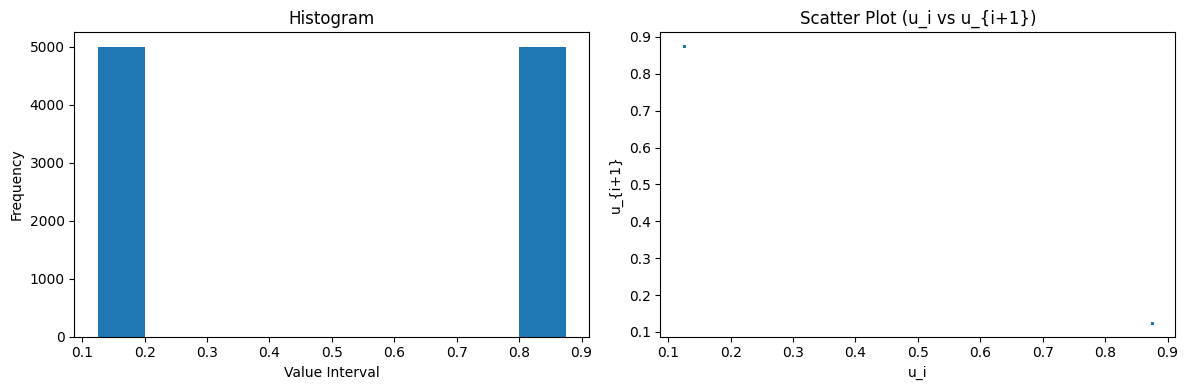

In [19]:
# Bad Generator
evaluate(x0=1, a=3, c=4, m=8)

Evaluation for x0=1, a=1103515245, c=12345, m=2147483648
Chi-Square: 8.836
KS Statistic: 0.0091
Correlation (h=1): 1.0928
Correlation (h=2): 1.7867
Correlation (h=3): 0.9976
Correlation (h=4): 0.6575
Correlation (h=5): 0.9631
Wald-Wolfowitz (Runs): 0.5477
Up-Down Test: 0.2056
Knuth Run-Length Test: 3.3822


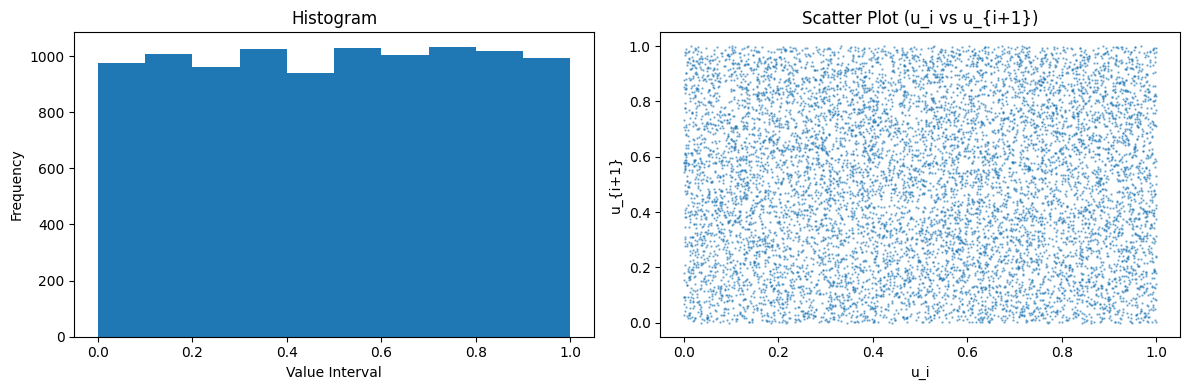

In [20]:
# Good Generator
evaluate(x0=1, a=1103515245, c=12345, m=2**31)

##### 2. System Generator Evaluation

System Generator
Chi-Square: 9.144
KS Statistic: 0.0085
Correlation (h=1): -1.1481
Correlation (h=2): -1.0514
Correlation (h=3): -0.7217
Correlation (h=4): -1.2922
Correlation (h=5): -0.8051
Wald-Wolfowitz (Runs): -0.0026
Up-Down Test: 0.4902
Knuth Run-Length Test: 8.9871


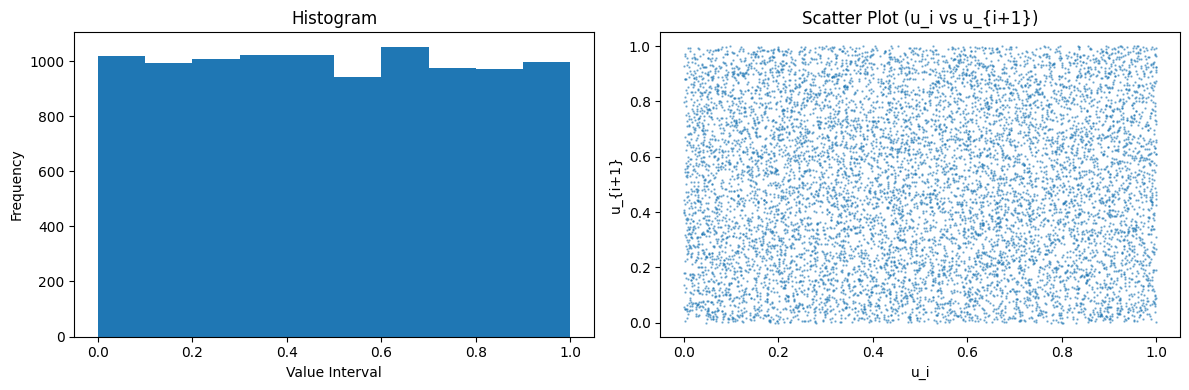

In [21]:
system_data = [random.random() for _ in range(10000)]

print("System Generator")
print(f"Chi-Square: {chi_square_test(system_data)}")
print(f"KS Statistic: {kolmogorov_smirnov_test(system_data):.4f}")
for h in range(1, 6):
        print(f"Correlation (h={h}): {correlation_test(system_data, h):.4f}")
print(f"Wald-Wolfowitz (Runs): {wald_wolfowitz_test(system_data):.4f}")
print(f"Up-Down Test: {up_down_test(system_data):.4f}")
print(f"Knuth Run-Length Test: {knuth_run_length_test(system_data):.4f}")

# Visualize the results
plot_analysis(system_data)